# 05_model_training — モデル学習

本番学習パイプラインと同一ロジックを使用:
- `LightGBMFeatureOptimizer` (前処理)
- `OptunaLightGBMOptimizer` (ハイパーパラメータ最適化)
- `lightgbm.train()` (本学習)

出力:
- `models/lgb_model.pkl` — モデルバンドル
- `reports/training_history.json` — 学習履歴

In [ ]:
import sys, json, importlib, os, time
from pathlib import Path
_NB_DIR = Path().resolve()
if _NB_DIR.name != 'notebooks': _NB_DIR = _NB_DIR.parent
if str(_NB_DIR) not in sys.path: sys.path.insert(0, str(_NB_DIR))
from utils.nb_config import *

_cfg_file = NB_DIR / 'config.json'
if _cfg_file.exists():
    _cfg = json.loads(_cfg_file.read_text(encoding='utf-8'))
    for _k in ('TARGET','RANDOM_STATE','CV_FOLDS','OPTUNA_TRIALS'):
        if _k in _cfg: globals()[_k] = _cfg[_k]

import pandas as pd
import numpy as np
try:
    import yaml
except Exception:
    yaml = None
import warnings
warnings.filterwarnings('ignore')
import lightgbm as lgb
import joblib

# ── モジュールを強制リロード（ファイル編集後に有効化）─────────
import keiba_ai.optuna_optimizer as _opt_module
import keiba_ai.gpu_utils as _gpu_module
import keiba_ai.lightgbm_feature_optimizer as _lgbf_module
import keiba_ai.training.pipeline as _tp_module
import keiba_ai.training.reporter as _trp_module
import keiba_ai.training.bundle as _tb_module
importlib.reload(_gpu_module)
importlib.reload(_lgbf_module)
importlib.reload(_opt_module)
importlib.reload(_tp_module)
importlib.reload(_trp_module)
importlib.reload(_tb_module)
from keiba_ai.optuna_optimizer import OptunaLightGBMOptimizer
from keiba_ai.gpu_utils import (
    detect_lightgbm_device,
    estimate_remaining_seconds,
    format_seconds,
    get_gpu_runtime_report,
    get_system_usage_snapshot,
    recommend_mode_from_gpu,
 )
from keiba_ai.lightgbm_feature_optimizer import resolve_training_mode, apply_gpu_mode_recommendation
from keiba_ai.optuna_runtime import (
    get_default_mode_presets,
    merge_mode_presets_from_yaml,
)

# ── 実行方針（根本対策）──────────────────────────────────────
RUN_LEGACY_PIPELINE = os.getenv('RUN_LEGACY_PIPELINE', '0') == '1'
USE_PRE_SPLIT_FROM_03 = os.getenv('USE_PRE_SPLIT_FROM_03', '1') == '1'
RUN_GPU_BENCHMARK = os.getenv('RUN_GPU_BENCHMARK', '0') == '1'

# ── LightGBM デバイス自動判定（GPU→CPUフォールバック）────────────
_device_override = os.getenv('LGBM_DEVICE', 'auto').strip().lower()
_prefer_gpu = os.getenv('LGBM_PREFER_GPU', '1') == '1'
if _device_override in ('gpu', 'cpu'):
    DEVICE = _device_override
    DEVICE_REASON = f'forced by LGBM_DEVICE={_device_override}'
else:
    DEVICE, DEVICE_REASON = detect_lightgbm_device(prefer_gpu=_prefer_gpu)

GPU_ENV_REPORT = get_gpu_runtime_report()
_gpu_name = GPU_ENV_REPORT.get('gpu_name', '')
_gpu_mem_total_mb = GPU_ENV_REPORT.get('gpu_memory_total_mb', np.nan)
_gpu_mem_used_mb = GPU_ENV_REPORT.get('gpu_memory_used_mb', np.nan)

if DEVICE != 'gpu' and _prefer_gpu:
    print('WARNING:')
    print('LightGBM GPU unavailable.')
    print('Fallback to CPU.')

# 通常学習ではGPUベンチマークを実行しない（時間増加を回避）
if not RUN_GPU_BENCHMARK:
    GPU_ENV_REPORT['lightgbm_gpu_available'] = False

# ── 学習モード設定（FAST / AUDIT / PROD + GPU推奨）────────────────────
AUDIT_MODE = os.getenv('AUDIT_MODE', '0') == '1'
FAST_MODE = os.getenv('FAST_MODE', '1') == '1'
USE_MEDIAN_PRUNER = True

_runtime = resolve_training_mode(
    fast_mode=FAST_MODE,
    audit_mode=AUDIT_MODE,
    n_trials_fast=10,
    n_trials_prod=30,
    n_trials_audit=20,
    n_splits_fast=3,
    n_splits_prod=5,
    n_splits_audit=3,
    boosting_fast='gbdt',
    boosting_prod='gbdt',
    boosting_audit='gbdt',
    num_boost_round_fast=200,
    num_boost_round_prod=500,
    num_boost_round_audit=150,
)

MODE_PRESETS = get_default_mode_presets()
_modes_yaml = NB_DIR / 'configs' / 'audit_modes.yaml'
try:
    MODE_PRESETS = merge_mode_presets_from_yaml(MODE_PRESETS, _modes_yaml, yaml)
except Exception as _mode_err:
    print(f'[MODE] yaml load skipped: {_mode_err}')

# GPU世代に基づく推奨モード自動選択（監査モード以外）
if not AUDIT_MODE and DEVICE == 'gpu':
    _gpu_rec = recommend_mode_from_gpu(_gpu_name)
    if _gpu_rec.get('fast_mode') is not None:
        _runtime = apply_gpu_mode_recommendation(
            _runtime,
            fast_mode=_gpu_rec.get('fast_mode'),
            n_trials=_gpu_rec.get('n_trials'),
            boosting_type=_gpu_rec.get('boosting_type'),
            n_splits_fast=3,
            n_splits_prod=5,
        )

# Notebook 05 の学習方針を固定（共通モード設定を適用）
_mode_name = str(_runtime.get('mode', 'prod')).lower()
if AUDIT_MODE:
    _mode_name = 'audit'
_mode_cfg = MODE_PRESETS.get(_mode_name, MODE_PRESETS['prod'])
_runtime.update({
    'mode': _mode_name,
    'n_trials': int(_mode_cfg.get('n_trials', 30)),
    'n_splits': int(_mode_cfg.get('n_splits', 5)),
    'boosting_type': str(_mode_cfg.get('boosting', 'gbdt')),
    'num_boost_round': int(_mode_cfg.get('num_boost_round', 500)),
})

N_TRIALS = int(_runtime['n_trials'])
CV_SPLITS = int(_runtime['n_splits'])
BOOSTING_TYPE = str(_runtime['boosting_type'])
NUM_BOOST_ROUND = int(_runtime['num_boost_round'])

# CPU環境では boosting_type を強制 gbdt
if DEVICE == 'cpu' and BOOSTING_TYPE != 'gbdt':
    BOOSTING_TYPE = 'gbdt'

SHAP_SAMPLE = 1000 if AUDIT_MODE else None

# ── GPU実利用確認の表示 ─────────────────────────────────────────
print('=' * 50)
print(f"LightGBM Version : {GPU_ENV_REPORT['lightgbm_version']}")
print(f"Device           : {DEVICE.upper()}")
print(f"GPU Name         : {_gpu_name}")
print(f"CUDA Version     : {GPU_ENV_REPORT.get('cuda_version', '')}")
if np.isfinite(_gpu_mem_used_mb) and np.isfinite(_gpu_mem_total_mb):
    print(f"GPU Memory       : {_gpu_mem_used_mb/1024.0:.1f} / {_gpu_mem_total_mb/1024.0:.1f} GB")
else:
    print('GPU Memory       : N/A')
print(f"nvidia-smi       : {GPU_ENV_REPORT.get('nvidia_smi_raw', '')}")
print('=' * 50)

# ── TARGET タイプ判定 ─────────────────────────────────────────
_REGRESSION_TARGETS = {'speed_deviation', 'rank'}
IS_REGRESSION = TARGET in _REGRESSION_TARGETS
print(f"TARGET={TARGET!r}  問題タイプ: {'回帰 (Regression)' if IS_REGRESSION else '分類 (Classification)'}")
print(f"MODE={_runtime['mode']}  FAST_MODE={FAST_MODE}  AUDIT_MODE={AUDIT_MODE}")
print(f"N_TRIALS={N_TRIALS}  CV_SPLITS={CV_SPLITS}  BOOSTING_TYPE={BOOSTING_TYPE}  NUM_BOOST_ROUND={NUM_BOOST_ROUND}")
print(f"MedianPruner={USE_MEDIAN_PRUNER}  SHAP_SAMPLE={SHAP_SAMPLE}")
print(f"RUN_LEGACY_PIPELINE={RUN_LEGACY_PIPELINE}  USE_PRE_SPLIT_FROM_03={USE_PRE_SPLIT_FROM_03}  RUN_GPU_BENCHMARK={RUN_GPU_BENCHMARK}")

# 03 の出力を読み込む
_cache = NB_DIR / 'data' / 'features' / 'features.pkl'
_data = joblib.load(_cache)
X_train = _data['X_train']
X_test  = _data['X_test']
y_train = _data['y_train']
y_test  = _data['y_test']
cat_features = _data['cat_features']
optimizer    = _data['optimizer']

# ── object/category 列を数値コードに変換（LightGBM DataFrame 入力条件）──
def _encode_object_cols(df: pd.DataFrame) -> pd.DataFrame:
    """object/category 列を float コードに変換して DataFrame を返す（列名は保持）"""
    _out = {}
    for col in df.columns:
        _s = df[col]
        if hasattr(_s, 'cat'):
            _codes = _s.cat.codes.astype(np.float32)
            _codes[_codes == -1] = np.nan
            _out[col] = _codes
        elif _s.dtype == object:
            _codes_int, _ = pd.factorize(_s)
            _arr = _codes_int.astype(np.float32)
            _arr[_arr == -1] = np.nan
            _out[col] = pd.Series(_arr, index=df.index)
        else:
            _out[col] = _s
    return pd.DataFrame(_out, index=df.index)

X_train = _encode_object_cols(X_train)
X_test  = _encode_object_cols(X_test)

if AUDIT_MODE:
    _sample_idx = X_train.sample(frac=0.2, random_state=42).index
    X_train = X_train.loc[_sample_idx].copy()
    y_train = y_train.loc[_sample_idx].copy()
    print(f"[AUDIT] train sample: {X_train.shape}")

if IS_REGRESSION:
    print(f"X_train: {X_train.shape}  y_train mean={y_train.mean():.4f}  std={y_train.std():.4f}")
else:
    print(f"X_train: {X_train.shape}  y_train 正例率: {y_train.mean()*100:.1f}%")
print(f"OPTUNA_TRIALS(original) = {OPTUNA_TRIALS}  CV_FOLDS(original) = {CV_FOLDS}")

# ── デバッグ: 文字列/カテゴリ列の確認 ─────────────────────────
_str_cols = [c for c in X_train.columns
             if X_train[c].dtype == object or hasattr(X_train[c], 'cat')]
if _str_cols:
    print(f"\n[DEBUG] 変換後も残る文字列/カテゴリ列 ({len(_str_cols)}列): {_str_cols[:5]}")
else:
    print("\n[DEBUG] 文字列/カテゴリ列なし（全列 数値型）")

LightGBM Version : 4.6.0
Device           : GPU
GPU Name         : NVIDIA GeForce RTX 4070 Ti SUPER
CUDA Version     : 13.1
GPU Memory       : 3.3 / 16.0 GB
nvidia-smi       : NVIDIA GeForce RTX 4070 Ti SUPER, 16376, 3406, 5, 1
TARGET='speed_deviation'  問題タイプ: 回帰 (Regression)
MODE=prod  FAST_MODE=True  AUDIT_MODE=False
N_TRIALS=30  CV_SPLITS=5  BOOSTING_TYPE=gbdt  NUM_BOOST_ROUND=500
MedianPruner=True  SHAP_SAMPLE=None
RUN_LEGACY_PIPELINE=False  USE_PRE_SPLIT_FROM_03=True  RUN_GPU_BENCHMARK=False
X_train: (134271, 146)  y_train mean=0.0000  std=0.8755
OPTUNA_TRIALS(original) = 5  CV_FOLDS(original) = 5

[DEBUG] 文字列/カテゴリ列なし（全列 数値型）


In [ ]:
# ── Legacy Step1: 無効化（TR-F/TR-G に統一）──────────────────────
if RUN_LEGACY_PIPELINE:
    print("RUN_LEGACY_PIPELINE=1 のため Legacy Step1 を実行します。")
    _cat_in_X = [c for c in cat_features if c in X_train.columns]
    if N_TRIALS > 0:
        optuna_opt = OptunaLightGBMOptimizer(
            n_trials=N_TRIALS,
            cv_folds=CV_SPLITS,
            random_state=RANDOM_STATE,
            direction='maximize',
            timeout=1800,
            is_regression=IS_REGRESSION,
            device_type=DEVICE,
            fixed_boosting_type=BOOSTING_TYPE,
            n_jobs=1,
            gc_after_trial=True,
        )
        print(f"Optuna 開始 ({N_TRIALS} trials, {CV_SPLITS}-fold CV, device={DEVICE})...")
        best_params, _opt_score = optuna_opt.optimize(X_train, y_train, _cat_in_X)
        best_params['boosting_type'] = BOOSTING_TYPE
        print(f"Best score: {_opt_score:.4f}")
        print(f"Best params: {best_params}")
    else:
        best_params = {
            'num_leaves': 63,
            'max_depth': 8,
            'min_child_samples': 20,
            'learning_rate': 0.05,
            'n_estimators': 500,
            'feature_fraction': 0.8,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'reg_alpha': 0.1,
            'reg_lambda': 0.1,
            'boosting_type': BOOSTING_TYPE,
        }
        print("N_TRIALS=0 のためデフォルトパラメータを使用")
else:
    print("[SKIP] Legacy Step1 は無効化されています（TR-F/TR-G を使用）。")

Optuna 開始 (100 trials, 5-fold CV, device=gpu)...


[I 2026-06-29 20:54:23,069] A new study created in memory with name: lightgbm_optimization


  y の NaN/inf 行を除去: 5147 行 → 378,485 行

[OPT-001] optimize()メソッド開始
[OPT-002] X.shape=(378485, 146), y.shape=(378485,)
[OPT-003] n_trials=100, cv_folds=5

  Optuna ハイパーパラメータ最適化開始
  試行回数: 100
  CVフォールド: 5
  データ数: 378485行 × 146列
  カテゴリカル特徴量: 5個
  タイムアウト: 1800秒

[OPT-004] スタディ作成開始
[OPT-005] スタディ作成完了
[OPT-006] ★★★ study.optimize()呼び出し直前 ★★★


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-29 20:57:17,889] Trial 0 finished with value: -0.9508249122553355 and parameters: {'n_estimators': 218, 'num_leaves': 123, 'max_depth': 8, 'min_child_samples': 64, 'min_child_weight': 0.00029380279387035364, 'learning_rate': 0.002051110418843397, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'feature_fraction': 0.8404460046972835, 'bagging_fraction': 0.8832290311184181, 'bagging_freq': 0, 'max_cat_to_onehot': 10, 'drop_rate': 0.41622132040021087, 'skip_drop': 0.10616955533913808}. Best is trial 0 with value: -0.9508249122553355.
[I 2026-06-29 20:57:38,023] Trial 1 finished with value: -0.9432496716285421 and parameters: {'n_estimators': 132, 'num_leaves': 48, 'max_depth': 5, 'min_child_samples': 57, 'min_child_weight': 0.0019762189340280074, 'learning_rate': 0.0038234752246751854, 'reg_alpha': 0.0032112643094417484, 'reg_lambda': 1.8007140198129195e-07, 'feature_fraction': 0.7168578594140873, 'bagging_fraction': 0.7465447373174767, 'bagging_freq': 3,

In [ ]:
# ── Legacy Step2: 無効化（TR-F/TR-G に統一）──────────────────────
if RUN_LEGACY_PIPELINE:
    from sklearn.model_selection import StratifiedKFold, KFold
    from sklearn.metrics import roc_auc_score, log_loss, mean_squared_error, mean_absolute_error

    _obj = 'regression' if IS_REGRESSION else 'binary'
    _metric = 'rmse' if IS_REGRESSION else 'auc'
    _cat_in_X = [c for c in cat_features if c in X_train.columns]
    _params = {
        **best_params,
        'objective': _obj,
        'metric': _metric,
        'boosting_type': BOOSTING_TYPE,
        'device_type': DEVICE,
        'verbose': -1,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
    }

    if IS_REGRESSION:
        _valid_cv_mask = y_train.notna().values
        _X_cv = X_train[_valid_cv_mask].reset_index(drop=True) if not _valid_cv_mask.all() else X_train
        _y_cv = y_train[_valid_cv_mask].reset_index(drop=True) if not _valid_cv_mask.all() else y_train
    else:
        _X_cv, _y_cv = X_train, y_train

    if IS_REGRESSION:
        _cv_splitter = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        _split_iter = _cv_splitter.split(_X_cv)
    else:
        _cv_splitter = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        _split_iter = _cv_splitter.split(_X_cv, _y_cv)

    _oof_pred = np.zeros(len(_X_cv))
    _models = []
    _cv_scores = []

    for fold_idx, (tr_idx, va_idx) in enumerate(_split_iter, 1):
        _X_tr, _X_va = _X_cv.iloc[tr_idx], _X_cv.iloc[va_idx]
        _y_tr, _y_va = _y_cv.iloc[tr_idx], _y_cv.iloc[va_idx]
        _clf = lgb.LGBMRegressor(**_params) if IS_REGRESSION else lgb.LGBMClassifier(**_params)
        _clf.fit(
            _X_tr, _y_tr,
            eval_set=[(_X_va, _y_va)],
            categorical_feature=_cat_in_X,
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)],
        )
        _oof_pred[va_idx] = _clf.predict(_X_va) if IS_REGRESSION else _clf.predict_proba(_X_va)[:, 1]
        _score = -np.sqrt(mean_squared_error(_y_va, _oof_pred[va_idx])) if IS_REGRESSION else roc_auc_score(_y_va, _oof_pred[va_idx])
        _cv_scores.append(_score)
        _models.append(_clf)
    print(f"CV mean: {np.mean(_cv_scores):.4f} ± {np.std(_cv_scores):.4f}")
else:
    print("[SKIP] Legacy Step2 は無効化されています（TR-F/TR-G を使用）。")

LightGBM Device: gpu
NaN 除去: 5147 行 → 378,485 行
Fold 1: neg-RMSE=-0.9567
Fold 2: neg-RMSE=-0.9550
Fold 3: neg-RMSE=-0.9549
Fold 4: neg-RMSE=-0.9504
Fold 5: neg-RMSE=-0.9542

CV mean: -0.9542 ± 0.0021
OOF RMSE: 0.9542


In [ ]:
# ── Legacy Step3: 無効化（TR-F/TR-G に統一）──────────────────────
if RUN_LEGACY_PIPELINE:
    from sklearn.metrics import roc_auc_score, log_loss, mean_squared_error, mean_absolute_error

    _cat_in_X = [c for c in cat_features if c in X_train.columns]
    _final_clf = lgb.LGBMRegressor(**_params) if IS_REGRESSION else lgb.LGBMClassifier(**_params)
    _final_clf.fit(
        _X_cv, _y_cv,
        categorical_feature=_cat_in_X,
        callbacks=[lgb.log_evaluation(period=-1)],
    )
    if IS_REGRESSION:
        _test_valid_mask = y_test.notna().values
        _y_test_clean = y_test[_test_valid_mask]
        _X_test_clean = X_test[_test_valid_mask]
        _test_pred = _final_clf.predict(_X_test_clean)
        _test_rmse = np.sqrt(mean_squared_error(_y_test_clean, _test_pred))
        _test_mae = mean_absolute_error(_y_test_clean, _test_pred)
        print(f"Test RMSE: {_test_rmse:.4f}")
        print(f"Test MAE: {_test_mae:.4f}")
    else:
        _test_proba = _final_clf.predict_proba(X_test)[:, 1]
        _test_auc = roc_auc_score(y_test, _test_proba)
        _test_logloss = log_loss(y_test, _test_proba)
        print(f"Test AUC: {_test_auc:.4f}")
        print(f"Test LogLoss: {_test_logloss:.4f}")
else:
    print("[SKIP] Legacy Step3 は無効化されています（TR-F/TR-G を使用）。")

Test RMSE: 0.9557
Test MAE:  0.7719


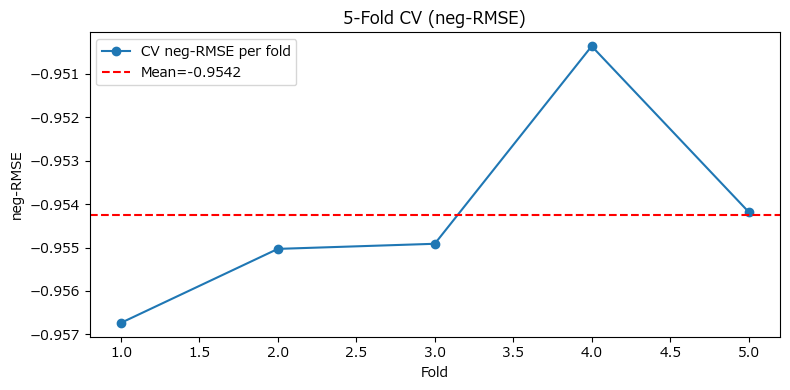

In [ ]:
# ── Legacy Step4: 無効化（TR-F/TR-G に統一）──────────────────────
if RUN_LEGACY_PIPELINE:
    import matplotlib.pyplot as plt
    import matplotlib
    matplotlib.rcParams['font.family'] = ['Meiryo', 'Yu Gothic', 'MS Gothic', 'DejaVu Sans']

    _metric_label = 'neg-RMSE' if IS_REGRESSION else 'AUC'
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, CV_SPLITS + 1), _cv_scores, marker='o', label=f'CV {_metric_label} per fold')
    ax.axhline(np.mean(_cv_scores), color='r', linestyle='--', label=f'Mean={np.mean(_cv_scores):.4f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(_metric_label)
    ax.set_title(f'{CV_SPLITS}-Fold CV ({_metric_label})')
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'cv_score.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("[SKIP] Legacy Step4 は無効化されています（TR-F/TR-G を使用）。")

In [ ]:
# ── Legacy Step5: 無効化（TR-F/TR-G に統一）──────────────────────
if RUN_LEGACY_PIPELINE:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    _bundle = {
        'model': _final_clf,
        'optimizer': optimizer,
        'cat_features': cat_features,
        'params': _params,
        'feature_cols': X_train.columns.tolist(),
        'target': TARGET,
        'task': 'regression' if IS_REGRESSION else 'classification',
    }
    joblib.dump(_bundle, MODELS_DIR / 'lgb_model.pkl')
    print(f"モデルバンドル保存: {MODELS_DIR / 'lgb_model.pkl'}")
else:
    print("[SKIP] Legacy Step5 は無効化されています（TR-F/TR-G を使用）。")

モデルバンドル保存: C:\Users\yuki2\Documents\ws\keiba-ai-pro\python-api\models\lgb_model.pkl
training_history.json 保存
{
  "trained_at": "2026-06-29T21:26:30.012369",
  "target": "speed_deviation",
  "task": "regression",
  "cv_folds": 5,
  "optuna_trials": 5,
  "cv_neg_rmse_mean": -0.9542,
  "cv_neg_rmse_std": 0.0021,
  "test_auc": NaN,
  "test_logloss": NaN,
  "best_params": {
    "n_estimators": 213,
    "num_leaves": 60,
    "max_depth": 3,
    "min_child_samples": 61,
    "min_child_weight": 0.003079128954681817,
    "learning_rate": 0.0013269122682658088,
    "reg_alpha": 8.474018099460245,
    "reg_lambda": 8.902994177443015e-05,
    "feature_fraction": 0.63900598736795,
    "bagging_fraction": 0.8833055785648228,
    "bagging_freq": 0,
    "max_cat_to_onehot": 4,
    "drop_rate": 0.4399862918668547,
    "skip_drop": 0.03611341326829713,
    "boosting_type": "dart",
    "objective": "regression",
    "metric": "rmse",
    "device_type": "gpu",
    "verbose": -1,
    "random_state": 42,
  

---
## Section 6 — 時系列スプリット & 本番トレーニング（feature_inspection より移行）

`feature_inspection.ipynb` Cell E-H より移行。  
`LightGBMFeatureOptimizer.fit_transform()` ではなく、
**時系列スプリット（`race_id` 日付接頭辞）** でトレーニングを行い、
モデルバンドルを `MODEL_STORE` と `MODELS_DIR` の両方に保存する。

| セル | 内容 |
|---|---|
| TR-E | パラメータ設定 / Optuna フラグ |
| TR-F | 時系列スプリット実行 |
| TR-G | Optuna → `lgb.train()` 学習 |
| TR-H | モデルバンドル保存 + 特徴量重要度 → FEATURE_STORE |


In [41]:
## ── TR-E: パラメータ設定 ─────────────────────────────────────────────────
# feature_inspection.ipynb Cell E より移行

# ────────────────────────────────────────────────────────────────
# 時系列スプリット設定
# ────────────────────────────────────────────────────────────────
TEST_DAYS   = 120     # 直近 N 日をテストセットに使用
USE_OPTUNA  = True    # False → LGB_PARAMS のデフォルト値で学習
SAVE_MODEL  = True    # MODEL_STORE + MODELS_DIR への保存

# Notebookモードに応じて最適化規模を自動切替（FAST/AUDIT/PROD）
TRIALS_TS = N_TRIALS
SPLITS_TS = CV_SPLITS
BOOSTING_TS = BOOSTING_TYPE
BOOST_ROUND_TS = NUM_BOOST_ROUND

# 監査モード時は共通設定を再適用
if AUDIT_MODE:
    _audit_cfg = MODE_PRESETS.get('audit', {})
    TRIALS_TS = int(_audit_cfg.get('n_trials', TRIALS_TS))
    SPLITS_TS = int(_audit_cfg.get('n_splits', SPLITS_TS))
    BOOST_ROUND_TS = int(_audit_cfg.get('num_boost_round', BOOST_ROUND_TS))
    BOOSTING_TS = str(_audit_cfg.get('boosting', BOOSTING_TS))
    USE_MEDIAN_PRUNER = True

# CPU環境では boosting_type を強制 gbdt
if DEVICE == 'cpu' and BOOSTING_TS != 'gbdt':
    BOOSTING_TS = 'gbdt'

# ────────────────────────────────────────────────────────────────
# LightGBM デフォルトパラメータ（Optuna 未使用時に使用）
# ────────────────────────────────────────────────────────────────
LGB_PARAMS_DEFAULT = {
    "binary": {
        "objective": "binary",
        "metric": "auc",
        "learning_rate": 0.05,
        "num_leaves": 63,
        "min_data_in_leaf": 30,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "lambda_l1": 0.1,
        "lambda_l2": 0.1,
        "verbose": -1,
    },
    "regression": {
        "objective": "regression",
        "metric": "rmse",
        "learning_rate": 0.05,
        "num_leaves": 63,
        "min_data_in_leaf": 30,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "verbose": -1,
    },
    "rank": {
        "objective": "lambdarank",
        "metric": "ndcg",
        "learning_rate": 0.05,
        "num_leaves": 63,
        "min_data_in_leaf": 30,
        "feature_fraction": 0.8,
        "verbose": -1,
    },
}

print(f"TEST_DAYS   : {TEST_DAYS} 日")
print(f"USE_OPTUNA  : {USE_OPTUNA}")
print(f"TARGET      : {TARGET}")
print(f"MODE        : {_runtime['mode']}")
print(f"TRIALS_TS   : {TRIALS_TS}  (QUICK_TEST=5 / FAST=10 / AUDIT=20 / PROD=30)")
print(f"SPLITS_TS   : {SPLITS_TS}")
print(f"BOOSTING_TS : {BOOSTING_TS}")
print(f"BOOST_ROUND : {BOOST_ROUND_TS}")
print(f"MedianPruner: {USE_MEDIAN_PRUNER}")
print(f"LightGBM Device: {DEVICE}")

TEST_DAYS   : 120 日
USE_OPTUNA  : True
TARGET      : speed_deviation
MODE        : prod
TRIALS_TS   : 30  (QUICK_TEST=5 / FAST=10 / AUDIT=20 / PROD=30)
SPLITS_TS   : 5
BOOSTING_TS : gbdt
BOOST_ROUND : 500
MedianPruner: True
LightGBM Device: gpu


In [42]:
# QUICK-TEST 設定（動作検証用トグル）
import os
QUICK_TEST = True  # 通常学習時は False
os.environ['QUICK_TEST'] = '1' if QUICK_TEST else '0'
print(f"[ENV] QUICK_TEST={os.environ['QUICK_TEST']}")

[ENV] QUICK_TEST=1


In [43]:
# ── TR-E2: 短時間検証オーバーライド（任意）────────────────────────────
_quick_test_env = os.getenv('QUICK_TEST', '0') == '1'
_quick_test_var = bool(globals().get('QUICK_TEST', False))
QUICK_TEST = _quick_test_var or _quick_test_env
if QUICK_TEST:
    _qt_cfg = MODE_PRESETS.get('quick_test', {'n_trials': 5, 'n_splits': 2, 'boosting': 'gbdt', 'num_boost_round': 150})
    TRIALS_TS_ORIG = TRIALS_TS
    SPLITS_TS_ORIG = SPLITS_TS
    TRIALS_TS = int(_qt_cfg.get('n_trials', 5))
    SPLITS_TS = int(_qt_cfg.get('n_splits', 2))
    BOOSTING_TS = str(_qt_cfg.get('boosting', 'gbdt'))
    BOOST_ROUND_TS = int(_qt_cfg.get('num_boost_round', BOOST_ROUND_TS))
    _runtime['mode'] = 'quick_test'
    RUN_GPU_BENCHMARK = False
    print(f"[QUICK-TEST] TRIALS_TS: {TRIALS_TS_ORIG} -> {TRIALS_TS}")
    print(f"[QUICK-TEST] SPLITS_TS: {SPLITS_TS_ORIG} -> {SPLITS_TS}")
    print(f"[QUICK-TEST] BOOSTING_TS={BOOSTING_TS}, BOOST_ROUND_TS={BOOST_ROUND_TS}")
    print(f"[QUICK-TEST] RUN_GPU_BENCHMARK={RUN_GPU_BENCHMARK}")
else:
    print('[QUICK-TEST] disabled (set QUICK_TEST=True in cell 10 or env QUICK_TEST=1)')

[QUICK-TEST] TRIALS_TS: 30 -> 5
[QUICK-TEST] SPLITS_TS: 5 -> 2
[QUICK-TEST] BOOSTING_TS=gbdt, BOOST_ROUND_TS=150
[QUICK-TEST] RUN_GPU_BENCHMARK=False


In [44]:
## ── TR-F: 時系列スプリット（高速経路）────────────────────────────────
import lightgbm as lgb

print("学習データ準備中…")
_pipeline_started_at = time.perf_counter()
_time_data_loading = 0.0
_time_feature_engineering = 0.0
_add_derived_features_called = False

if USE_PRE_SPLIT_FROM_03:
    # 03_feature_engineering の成果物をそのまま使い、再ロード/再特徴量生成を避ける
    _t0 = time.perf_counter()
    _X_tr_ts = _encode_object_cols(X_train.copy()).reset_index(drop=True)
    _X_te_ts = _encode_object_cols(X_test.copy()).reset_index(drop=True)
    _y_tr_ts = pd.Series(y_train).reset_index(drop=True)
    _y_te_ts = pd.Series(y_test).reset_index(drop=True)
    _time_data_loading = time.perf_counter() - _t0

    _cat_tr_ts = [c for c in cat_features if c in _X_tr_ts.columns]
    _cat_te_ts = _cat_tr_ts
    _id_drop = {TARGET, 'race_id', 'horse_id', 'jockey_id', 'trainer_id', 'owner_id'}
    _feat_cols_ts = [c for c in _X_tr_ts.columns if c not in _id_drop]
    _X_tr_ts = _X_tr_ts[_feat_cols_ts]
    _X_te_ts = _X_te_ts.reindex(columns=_feat_cols_ts, fill_value=0)

    # 後段保存用の互換情報
    _cutoff = pd.Timestamp(TEST_START) if 'TEST_START' in globals() else pd.Timestamp('2000-01-01')
    _df_ts_tr = pd.DataFrame(index=_X_tr_ts.index)
    _df_ts_te = pd.DataFrame(index=_X_te_ts.index)

    print("[FAST-PATH] 03のfeatures.pklを使用（再特徴量生成なし）")
else:
    # 必要時のみ重処理経路を許可
    from keiba_ai.db_ultimate_loader import load_ultimate_training_frame
    from keiba_ai.feature_engineering import add_derived_features
    from keiba_ai.lightgbm_feature_optimizer import LightGBMFeatureOptimizer

    _t0 = time.perf_counter()
    _raw_tr = load_ultimate_training_frame(get_db_path(DATA_SOURCE_MODE))
    _time_data_loading = time.perf_counter() - _t0

    _t1 = time.perf_counter()
    _add_derived_features_called = True
    feature_df = add_derived_features(_raw_tr)
    feature_df = feature_df.reset_index(drop=True)
    _time_feature_engineering = time.perf_counter() - _t1

    def _make_target_ts(df: pd.DataFrame, target_col: str) -> pd.Series:
        if target_col in ('win', 'top3'):
            finish = df.get('finish_order', df.get('finish', pd.Series(dtype=float, index=df.index)))
            return (finish == 1).astype(int) if target_col == 'win' else (finish <= 3).astype(int)
        if target_col == 'speed_deviation':
            _ts = pd.to_numeric(df.get('time_seconds', pd.Series(dtype=float, index=df.index)), errors='coerce')
            _dist = pd.to_numeric(df.get('distance', pd.Series(dtype=float, index=df.index)), errors='coerce')
            _spd = _dist / _ts.replace(0, np.nan)
            if 'race_id' in df.columns:
                _grp_mean = _spd.groupby(df['race_id']).transform('mean')
                _grp_std = _spd.groupby(df['race_id']).transform('std').replace(0, np.nan)
            else:
                _grp_mean = _spd.mean()
                _grp_std = _spd.std() or np.nan
            return (_spd - _grp_mean) / _grp_std
        if target_col == 'rank':
            for _c in ['finish_position', 'finish_order', 'finish']:
                if _c in df.columns:
                    return df[_c].copy()
            return pd.Series(dtype=float, index=df.index)
        if target_col in df.columns:
            return df[target_col].copy()
        raise ValueError(f'Unknown target: {target_col}')

    _y_all = _make_target_ts(feature_df, TARGET)
    _valid_pos = np.where(_y_all.notna().values)[0]
    _df_ts = feature_df.iloc[_valid_pos].copy()
    _y_ts = pd.Series(_y_all.values[_valid_pos], index=_df_ts.index, name=TARGET)

    _df_ts['_date_ts'] = pd.to_datetime(_df_ts['race_id'].astype(str).str[:8], format='%Y%m%d', errors='coerce')
    _max_date = _df_ts['_date_ts'].max()
    _cutoff = _max_date - pd.Timedelta(days=TEST_DAYS)

    _tr_mask_ts = _df_ts['_date_ts'] <= _cutoff
    _te_mask_ts = _df_ts['_date_ts'] > _cutoff
    _df_ts_tr = _df_ts[_tr_mask_ts].copy()
    _df_ts_te = _df_ts[_te_mask_ts].copy()
    _y_tr_ts = _y_ts[_tr_mask_ts]
    _y_te_ts = _y_ts[_te_mask_ts]
    _df_ts.drop(columns=['_date_ts'], inplace=True, errors='ignore')
    _df_ts_tr.drop(columns=['_date_ts'], inplace=True, errors='ignore')
    _df_ts_te.drop(columns=['_date_ts'], inplace=True, errors='ignore')

    _opt_ts = LightGBMFeatureOptimizer()
    _X_tr_ts, _cat_tr_ts = _opt_ts.fit_transform(_df_ts_tr.copy(), target_col=TARGET)
    _X_te_ts = _opt_ts.transform(_df_ts_te.copy())
    _cat_te_ts = _cat_tr_ts

    _id_drop = {TARGET, 'race_id', 'horse_id', 'jockey_id', 'trainer_id', 'owner_id'}
    _feat_cols_ts = [c for c in _X_tr_ts.columns if c not in _id_drop]
    _X_tr_ts = _encode_object_cols(_X_tr_ts[_feat_cols_ts])
    _X_te_ts = _encode_object_cols(_X_te_ts.reindex(columns=_feat_cols_ts, fill_value=0))

if USE_PRE_SPLIT_FROM_03 and _add_derived_features_called:
    raise RuntimeError("USE_PRE_SPLIT_FROM_03=True なのに add_derived_features が呼ばれています")
print(f"[VERIFY] add_derived_features called: {_add_derived_features_called}")

print(f"_X_tr_ts: {_X_tr_ts.shape}  _X_te_ts: {_X_te_ts.shape}")
print(f"Data loading time       : {format_seconds(_time_data_loading)}")
print(f"Feature engineering time: {format_seconds(_time_feature_engineering)}")
assert _X_tr_ts.shape[1] == _X_te_ts.shape[1], f"列数不一致: train={_X_tr_ts.shape[1]}, test={_X_te_ts.shape[1]}"

学習データ準備中…
[FAST-PATH] 03のfeatures.pklを使用（再特徴量生成なし）
[VERIFY] add_derived_features called: False
_X_tr_ts: (134271, 146)  _X_te_ts: (36344, 146)
Data loading time       : 0s
Feature engineering time: 0s


In [45]:
# ── TR-F2: NaN安全化（短時間検証/本番共通）────────────────────────────
_tr_mask_notna = pd.Series(_y_tr_ts).notna().values
_te_mask_notna = pd.Series(_y_te_ts).notna().values
_drop_tr = int((~_tr_mask_notna).sum())
_drop_te = int((~_te_mask_notna).sum())
if _drop_tr > 0:
    _X_tr_ts = _X_tr_ts.loc[_tr_mask_notna].reset_index(drop=True)
    _y_tr_ts = pd.Series(_y_tr_ts).loc[_tr_mask_notna].reset_index(drop=True)
if _drop_te > 0:
    _X_te_ts = _X_te_ts.loc[_te_mask_notna].reset_index(drop=True)
    _y_te_ts = pd.Series(_y_te_ts).loc[_te_mask_notna].reset_index(drop=True)
print(f"[SANITIZE] dropped train NaN targets: {_drop_tr}")
print(f"[SANITIZE] dropped test NaN targets: {_drop_te}")
print(f"[SANITIZE] train={len(_y_tr_ts):,}, test={len(_y_te_ts):,}")

[SANITIZE] dropped train NaN targets: 4456
[SANITIZE] dropped test NaN targets: 969
[SANITIZE] train=129,815, test=35,375


In [49]:
## ── TR-G: Optuna -> lgb.train() 学習 ──────────────────────────────────────
# feature_inspection.ipynb Cell G より移行

from keiba_ai.training.reporter import print_training_summary
from keiba_ai.training.pipeline import run_notebook_pipeline

_result_ts = run_notebook_pipeline(
    target=TARGET,
    runtime=_runtime,
    audit_mode=AUDIT_MODE,
    quick_test=bool(globals().get("QUICK_TEST", False)),
    random_state=RANDOM_STATE,
    use_optuna=USE_OPTUNA,
    use_median_pruner=USE_MEDIAN_PRUNER,
    mode_presets=MODE_PRESETS,
    reports_dir=REPORTS_DIR,
    gpu_env_report=GPU_ENV_REPORT,
    device=DEVICE,
    boosting_ts=BOOSTING_TS,
    boost_round_ts=BOOST_ROUND_TS,
    trials_ts=TRIALS_TS,
    splits_ts=SPLITS_TS,
    X_train=_X_tr_ts,
    y_train=_y_tr_ts,
    X_test=_X_te_ts,
    y_test=_y_te_ts,
    cat_train=_cat_tr_ts,
    cat_test=_cat_te_ts,
    feat_cols=_feat_cols_ts,
    lgb_params_default=LGB_PARAMS_DEFAULT,
    run_gpu_benchmark=RUN_GPU_BENCHMARK,
    time_data_loading=_time_data_loading,
    time_feature_engineering=_time_feature_engineering,
    pipeline_started_at=_pipeline_started_at,
    estimate_remaining_seconds=estimate_remaining_seconds,
    format_seconds=format_seconds,
    get_system_usage_snapshot=get_system_usage_snapshot,
)

_task_ts = _result_ts["task"]
_mode_name_ts = _result_ts["mode_name"]
TRIALS_TS = int(_result_ts["trials_ts"])
SPLITS_TS = int(_result_ts["splits_ts"])

_model_ts = _result_ts["model"]
_best_iter_ts = int(_result_ts["best_iter"])
_best_params_ts = _result_ts["best_params"]
_opt_score_ts = _result_ts["opt_score"]
_metrics_ts = _result_ts["metrics"]
_best_rmse = float(_result_ts["best_rmse"])

_training_total_seconds = float(_result_ts["training_total_seconds"])
_training_model_seconds = float(_result_ts["training_model_seconds"])
_optuna_total_seconds = float(_result_ts["optuna_total_seconds"])
_cv_seconds = float(_result_ts["cv_seconds"])
_avg_trial_seconds = float(_result_ts["avg_trial_seconds"])
_gpu_speedup = float(_result_ts["gpu_speedup"])

_runtime_table_df = _result_ts["runtime_table_df"]
_runtime_breakdown_csv = _result_ts["runtime_breakdown_csv"]
_trial_log_csv = _result_ts["trial_log_csv"]
_trial_timing_csv = _result_ts["trial_timing_csv"]
_gpu_usage_csv = _result_ts["gpu_usage_csv"]
_system_usage_csv = _result_ts["system_usage_csv"]
_gpu_benchmark_csv = _result_ts["gpu_benchmark_csv"]

_final_train_boosting = str(_best_params_ts.get("boosting_type", "gbdt"))
print_training_summary(
    device=DEVICE,
    training_total_seconds=_training_total_seconds,
    avg_trial_seconds=_avg_trial_seconds,
    best_rmse=_best_rmse,
    best_params=_best_params_ts,
    final_train_boosting=_final_train_boosting,
    gpu_speedup=_gpu_speedup,
    runtime_table_df=_runtime_table_df,
)

print(f"trial log: {_trial_log_csv}")
print(f"trial timing: {_trial_timing_csv}")
print(f"runtime breakdown: {_runtime_breakdown_csv}")

[I 2026-07-04 19:52:59,939] A new study created in memory with name: no-name-a32cd3d7-d349-475f-b3ee-2fff15c88d55


Optuna ハイパーパラメータ最適化 開始…
Trials=5, Splits=2, Boosting=gbdt
MedianPruner enabled: True
[TRIAL START] trial=0 started_at=2026-07-04T19:52:59.940029


[I 2026-07-04 19:53:06,343] Trial 0 finished with value: -0.7719899590740844 and parameters: {'learning_rate': 0.056217808319315374, 'num_leaves': 93, 'max_depth': 7, 'min_child_samples': 56, 'feature_fraction': 0.6624074561769746, 'bagging_fraction': 0.662397808134481, 'bagging_freq': 0, 'lambda_l1': 0.6245760287469893, 'lambda_l2': 0.002570603566117598, 'num_boost_round': 136}. Best is trial 0 with value: -0.7719899590740844.


[TRIAL END] trial=0 elapsed=6.40s objective=-0.771990
[TRIAL ETA] avg=6.40s remaining=25s
Trial 1/5
Average Trial : 6 sec
Estimated Remaining : 25s
[TRIAL START] trial=1 started_at=2026-07-04T19:53:06.419769


[I 2026-07-04 19:53:12,127] Trial 1 finished with value: -0.776999434560273 and parameters: {'learning_rate': 0.03144091460070617, 'num_leaves': 95, 'max_depth': 7, 'min_child_samples': 32, 'feature_fraction': 0.6727299868828402, 'bagging_fraction': 0.6733618039413735, 'bagging_freq': 3, 'lambda_l1': 0.00052821153945323, 'lambda_l2': 7.71800699380605e-05, 'num_boost_round': 114}. Best is trial 1 with value: -0.776999434560273.


...

[TRIAL END] trial=2 elapsed=1.89s objective=-0.778719
[TRIAL ETA] avg=4.67s remaining=9s
Trial 3/5
Average Trial : 4 sec
Estimated Remaining : 9s
[TRIAL START] trial=3 started_at=2026-07-04T19:53:14.160317


[I 2026-07-04 19:53:15,873] Trial 3 finished with value: -0.7822250528798114 and parameters: {'learning_rate': 0.07252813963310069, 'num_leaves': 42, 'max_depth': 3, 'min_child_samples': 77, 'feature_fraction': 0.9862528132298237, 'bagging_fraction': 0.9233589392465844, 'bagging_freq': 3, 'lambda_l1': 7.569183361880229e-08, 'lambda_l2': 0.014391207615728067, 'num_boost_round': 122}. Best is trial 3 with value: -0.7822250528798114.


[TRIAL END] trial=3 elapsed=1.71s objective=-0.782225
[TRIAL ETA] avg=3.93s remaining=3s
Trial 4/5
Average Trial : 4 sec
Estimated Remaining : 4s
[TRIAL START] trial=4 started_at=2026-07-04T19:53:15.942852


[I 2026-07-04 19:53:17,529] Trial 4 finished with value: -0.7930084880556051 and parameters: {'learning_rate': 0.03854267643913452, 'num_leaves': 63, 'max_depth': 3, 'min_child_samples': 75, 'feature_fraction': 0.7035119926400067, 'bagging_fraction': 0.8650089137415928, 'bagging_freq': 3, 'lambda_l1': 0.0004793052550782129, 'lambda_l2': 0.0008325158565947976, 'num_boost_round': 109}. Best is trial 4 with value: -0.7930084880556051.


[TRIAL END] trial=4 elapsed=1.59s objective=-0.793008
[TRIAL ETA] avg=3.46s remaining=0s
Trial 5/5
Average Trial : 3 sec
Estimated Remaining : 0s
[50]	valid_0's rmse: 0.815612
[100]	valid_0's rmse: 0.801295

Training Summary
Device                : GPU
Total Time            : 18 sec
Average Trial         : 3 sec
Best RMSE             : 0.7997913696463912
Best Parameters       : {'objective': 'regression', 'metric': 'rmse', 'learning_rate': 0.03854267643913452, 'num_leaves': 63, 'min_data_in_leaf': 30, 'feature_fraction': 0.7035119926400067, 'bagging_fraction': 0.8650089137415928, 'bagging_freq': 3, 'verbose': -1, 'boosting_type': 'gbdt', 'device_type': 'gpu', 'verbosity': -1, 'seed': 42, 'num_threads': 16, 'max_bin': 255, 'gpu_use_dp': False, 'max_depth': 3, 'min_child_samples': 75, 'lambda_l1': 0.0004793052550782129, 'lambda_l2': 0.0008325158565947976}
Final Boosting        : gbdt
GPU Speedup           : N/A 倍

Runtime Breakdown Table
              stage    seconds formatted
         

In [50]:
## ── TR-H: モデルバンドル保存 + FEATURE_STORE ──────────────────────────────
# feature_inspection.ipynb Cell H より移行
# ─ MODEL_STORE  : Notebook 間受け渡し用 (.pkl)
# ─ MODELS_DIR   : 本番 API 参照用 (.pkl + metadata.json)
# ─ FEATURE_STORE: feature_importance を 04 に渡す

from keiba_ai.training.bundle import (
    build_feature_importance_df,
    build_model_bundle,
    save_model_bundle,
)

# ── 特徴量重要度 DataFrame ────────────────────────────────────────────────
_imp_nb = build_feature_importance_df(_model_ts)

# ── バンドル構成 ──────────────────────────────────────────────────────────
_bundle_ts = build_model_bundle(
    model=_model_ts,
    feature_cols=_feat_cols_ts,
    cat_features=[c for c in _cat_tr_ts if c in _feat_cols_ts],
    target=TARGET,
    task=_task_ts,
    metrics=_metrics_ts,
    best_iteration=int(_best_iter_ts),
    params=_best_params_ts,
    feature_importance=_imp_nb,
    test_days=TEST_DAYS,
    cutoff_date=str(_cutoff.date()),
    mode=_runtime["mode"],
    fast_mode=FAST_MODE,
    audit_mode=AUDIT_MODE,
    device_type=DEVICE,
    gpu_env_report=GPU_ENV_REPORT,
    optuna_trials=TRIALS_TS,
    cv_splits=SPLITS_TS,
    total_training_seconds=float(_training_total_seconds),
    avg_trial_seconds=(float(_avg_trial_seconds) if np.isfinite(_avg_trial_seconds) else None),
    gpu_speedup=(float(_gpu_speedup) if "_gpu_speedup" in globals() and np.isfinite(_gpu_speedup) else None),
    runtime_breakdown=_runtime_table_df.to_dict(orient="records") if "_runtime_table_df" in globals() else [],
    reports_dir=REPORTS_DIR,
)

if SAVE_MODEL:
    _saved_bundle_paths = save_model_bundle(
        bundle=_bundle_ts,
        target=TARGET,
        models_dir=MODELS_DIR,
        feature_importance=_imp_nb,
        save_store_fn=save_store,
        model_store=MODEL_STORE,
        feature_store=FEATURE_STORE,
    )
    print(f"  ✓ 本番保存: {_saved_bundle_paths['model_path'].name}")
    print(f"  ✓ metadata: {_saved_bundle_paths['meta_path'].name}")

# ── サマリー ─────────────────────────────────────────────────────────────
print(f"\n──── 学習サマリー ────")
print(f"  Target       : {TARGET}")
print(f"  Task         : {_task_ts}")
print(f"  Mode         : {_runtime['mode']}")
print(f"  Device       : {DEVICE}")
print(f"  LightGBM     : {GPU_ENV_REPORT.get('lightgbm_version', '')}")
print(f"  CUDA         : {GPU_ENV_REPORT.get('cuda_version', '')}")
print(f"  GPU name     : {GPU_ENV_REPORT.get('gpu_name', '')}")
print(f"  Train rows   : {len(_X_tr_ts):,}")
print(f"  Test rows    : {len(_X_te_ts):,}")
print(f"  Features     : {len(_feat_cols_ts)}")
print(f"  Best iter    : {_best_iter_ts}")
print(f"  Total time   : {format_seconds(_training_total_seconds)}")
if np.isfinite(_avg_trial_seconds):
    print(f"  Avg trial    : {format_seconds(_avg_trial_seconds)}")
if "_gpu_speedup" in globals() and np.isfinite(_gpu_speedup):
    print(f"  GPU speedup  : {round(_gpu_speedup, 2)}x")
for k, v in _metrics_ts.items():
    print(f"  {k:>10}   : {v}")
print(f"\n  Top-10 feature importance (gain):")
print(_imp_nb.head(10)[["feature", "gain"]].to_string(index=False))

  ✓ model_store/lgb_model_speed_deviation.pkl  (118.7 KB)
  ✓ feature_store/feature_importance_speed_deviation.pkl  (5.8 KB)
  ✓ 本番保存: lgb_model_speed_deviation.pkl
  ✓ metadata: lgb_model_speed_deviation_meta.json

──── 学習サマリー ────
  Target       : speed_deviation
  Task         : regression
  Mode         : quick_test
  Device       : gpu
  LightGBM     : 4.6.0
  CUDA         : 13.1
  GPU name     : NVIDIA GeForce RTX 4070 Ti SUPER
  Train rows   : 129,815
  Test rows    : 35,375
  Features     : 146
  Best iter    : 109
  Total time   : 18s
  Avg trial    : 3s
        rmse   : 0.7998
        corr   : 0.4197

  Top-10 feature importance (gain):
                 feature         gain
        prev_race_finish 32676.111580
    recent_form_weighted 29472.367645
       recent_form_5race 27361.118166
    horse_speed_rank_pct 24799.987701
    race_avg_prev_finish 19283.618562
       speed_vs_race_avg 16580.346599
   jockey_close_win_rate 13204.624115
    horse_speed_exp_mean  7966.342646
  j